## HW04 – Predicting a Burglary or more in a week within a given Subzone with the Crime Dataset

**By Wasim Raja Mondal**

### 1. Create a Jupyter Notebook.

In [1]:
!pwd #created a notebook and working inside the directory HW04

/Users/wasim/Desktop/HW04


### 2. Import Libraries

In [2]:
!pip install numpy #installing numpy
!pip install pandas #installing pandas
!pip install matplotlib #installing matplotlib
!pip install seaborn #installing seaborn
!pip install statsmodels #installing statmodel
!pip install scikit-learn #installing scikit learn
import numpy as np  #importing numpy
import pandas as pd #importing pandas
import seaborn as sns #importing seaborn
import pandas as pd #importing pandas
import statsmodels  #importing statmodels
import statsmodels.api as sm
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500) #allows for up to 500 columns to be displayed when viewing a dataframe
plt.style.use("seaborn-v0_8-whitegrid") ##a style that can be used for plots
import datetime as dt #importing datetime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### 3. Import Data 

* Import Burglary_Week_HW04.csv and name it df_canton_all

In [3]:
df_canton_all = pd.read_csv('data/Burglary_Week_HW04.csv', index_col=None, header=0)

In [4]:
df_canton_all.head()

,Subzone,YEAR_WEEK,SUB_YEAR_WEEK,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,PredictedBurg,ActualBurg,BurgStatus,BurgStatus2
0,ZONE1A,2009_1,2009_1_ZONE1A,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0,0,0
1,ZONE1B,2009_1,2009_1_ZONE1B,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0,0,0
2,ZONE1C,2009_1,2009_1_ZONE1C,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0,0,0
3,ZONE1D,2009_1,2009_1_ZONE1D,189,0,18,9,27,63,0,27,189,9,27,18,9,9,18,0,9,0,0,0,0,0,0,0
4,ZONE2A,2009_1,2009_1_ZONE2A,36,4,0,0,4,12,12,4,36,0,16,0,0,0,0,0,12,0,0,0,0,0,0,0


In [5]:
df_canton_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11868 entries, 0 to 11867
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Subzone          11868 non-null  object
 1   YEAR_WEEK        11868 non-null  object
 2   SUB_YEAR_WEEK    11868 non-null  object
 3   All_comp         11868 non-null  int64 
 4   FalseAlarm_comp  11868 non-null  int64 
 5   Arrest_comp      11868 non-null  int64 
 6   Cleared_comp     11868 non-null  int64 
 7   NoContact_comp   11868 non-null  int64 
 8   NoReport_comp    11868 non-null  int64 
 9   Resolved_comp    11868 non-null  int64 
 10  Filed_comp       11868 non-null  int64 
 11  Calls_comp       11868 non-null  int64 
 12  BurgAlarm_comp   11868 non-null  int64 
 13  Suspicious_comp  11868 non-null  int64 
 14  Shots_comp       11868 non-null  int64 
 15  Intox_comp       11868 non-null  int64 
 16  Drugs_comp       11868 non-null  int64 
 17  Assault_comp     11868 non-null

* Import CantonPoliceDept_HW04.csv and name it df_canton

In [6]:
df_canton = pd.read_csv('data/CantonPoliceDept_HW04.csv', index_col=None, header=0)

In [7]:
df_canton.head()

,SUB_YEAR_WEEK,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire)
0,2009_1_ZONE3B,2009_2_ZONE3B,2,0,1,1,2009,2,1,0,1,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
1,2009_1_ZONE2D,2009_2_ZONE2D,1,0,1,1,2009,2,0,0,1,1,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0
2,2009_2_ZONE6C,2009_3_ZONE6C,23,2,2,1,2009,24,7,1,3,4,6,2,3,26,0,0,0,0,0,0,0,0,0,0,0,0,0,8,2,1,3,0,0,0,1,4,0,0,0,0,0,1,0,1,0,1,4,0,0,0,0,0,0,1,0,0,0,0,0,6,0,0,0,0,0,0,1,0,3,8,0,0,3,4,0,0,0,0,0,0
3,2009_2_ZONE1C,2009_3_ZONE1C,31,3,2,1,2009,34,8,7,2,5,3,1,6,32,0,0,0,0,0,0,0,0,0,0,0,0,2,4,3,1,9,0,0,0,1,0,1,0,0,0,0,1,0,5,0,4,1,0,0,0,0,0,0,1,0,0,0,0,3,3,0,0,0,0,0,0,0,0,5,7,0,0,4,9,0,0,0,0,0,0
4,2009_2_ZONE2A,2009_3_ZONE2A,24,6,2,1,2009,12,2,2,3,0,0,2,1,10,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,2,1,0,0,0,0,0,0,0,1,0,0,0,0,2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,2,4,0,0,2,0,0,0,0,0,0,0


In [8]:
df_canton.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11015 entries, 0 to 11014
Data columns (total 82 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   SUB_YEAR_WEEK                         11015 non-null  object
 1   SUB_YEAR_WEEK_target                  11015 non-null  object
 2   call_ALL_target                       11015 non-null  int64 
 3   call_Burglary_target                  11015 non-null  int64 
 4   WEEK                                  11015 non-null  int64 
 5   MONTH                                 11015 non-null  int64 
 6   YEAR                                  11015 non-null  int64 
 7   call_ALL                              11015 non-null  int64 
 8   Friday                                11015 non-null  int64 
 9   Monday                                11015 non-null  int64 
 10  Saturday                              11015 non-null  int64 
 11  Sunday                      

* Import Census_Subzone_HW04.csv and name it df_census

In [9]:
df_census = pd.read_csv('data/Census_Subzone_HW04.csv', index_col=None, header=0)

In [10]:
df_census.head()

,Subzone,SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita
0,ZONE1A,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862
1,ZONE1B,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271
2,ZONE1C,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.023102,0.000000,0.854785,229,1.000000,0.296943,0.056769,0.165939,0.021834,45,37,46,22150,65078.29167,18068,34792,14181
3,ZONE1D,1.306158e+08,182,4522,0.507519,0.492481,2366,0.988588,0.883770,0.087489,4358,0.267324,0.011014,0.006884,0.109224,0.028683,0.732676,1657,1.000000,0.042245,0.166566,0.064575,0.050694,31,28,32,33225,35873.00000,32084,44433,20857
4,ZONE2A,6.732244e+07,75,2891,0.578692,0.421308,973,1.000000,0.850976,0.123330,2846,0.165847,0.000000,0.014406,0.031975,0.004216,0.834153,581,1.000000,0.106713,0.092943,0.184165,0.115318,38,39,37,45937,50703.00000,27333,54733,22852


In [11]:
df_census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Subzone                                   24 non-null     object 
 1   SqFootage                                 24 non-null     float64
 2   HousingUnits                              24 non-null     int64  
 3   Population                                24 non-null     int64  
 4   Population_Male                           24 non-null     float64
 5   Population_Female                         24 non-null     float64
 6   Worked                                    24 non-null     int64  
 7   Workers who travel to work                24 non-null     float64
 8   Drove alone to Work                       24 non-null     float64
 9   Carpooled to Work                         24 non-null     float64
 10  Population_3andover                     

## 4. Merge the datasets together to create df_all

* 4.1 Merge df_canton_all, df_canton, and df_census into one dataset

* 4.1.a Merge df_canton_all + df_canton

In [12]:
df_all = pd.merge(
    df_canton_all,     # LEFT (keep all rows)
    df_canton,         # RIGHT
    how="left",        # LEFT JOIN
    on="SUB_YEAR_WEEK"
)


In [13]:
df_all.head()

,Subzone,YEAR_WEEK,SUB_YEAR_WEEK,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,PredictedBurg,ActualBurg,BurgStatus,BurgStatus2,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire)
0,ZONE1A,2009_1,2009_1_ZONE1A,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ZONE1B,2009_1,2009_1_ZONE1B,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ZONE1C,2009_1,2009_1_ZONE1C,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ZONE1D,2009_1,2009_1_ZONE1D,189,0,18,9,27,63,0,27,189,9,27,18,9,9,18,0,9,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ZONE2A,2009_1,2009_1_ZONE2A,36,4,0,0,4,12,12,4,36,0,16,0,0,0,0,0,12,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* 4.1.b. Merge df_census

In [14]:
df_all = pd.merge(
    df_all,            # LEFT (keep all rows)
    df_census,         # RIGHT
    how="left",        # LEFT JOIN
    on="Subzone"
)

* 4.1.c. Replace Missing Weekly Crime Data with 0

In [15]:
canton_cols = [c for c in df_canton.columns if c != "SUB_YEAR_WEEK"]
df_all[canton_cols] = df_all[canton_cols].fillna(0)

## 5. Create the datasets

**5.1. Create the X and y datasets**

* 5.1.a Create the y dataset – the target variable (BurgStatus)

In [16]:
y = df_all["BurgStatus"]

In [17]:
y.value_counts()

BurgStatus
0    7595
1    4273
Name: count, dtype: int64

In [18]:
round(y.value_counts(normalize=True), 3)

BurgStatus
0    0.64
1    0.36
Name: proportion, dtype: float64

So 64% 0 BurgerStatus and 36% 1 BurgerStatus

* 5.1.b Create the X dataset – features

In [19]:
X=df_all.drop(['BurgStatus'], axis=1)

In [20]:
X.columns

Index(['Subzone', 'YEAR_WEEK', 'SUB_YEAR_WEEK', 'All_comp', 'FalseAlarm_comp',
       'Arrest_comp', 'Cleared_comp', 'NoContact_comp', 'NoReport_comp',
       'Resolved_comp',
       ...
       'Households_SSI', 'Households_publicassistanceincome',
       'MedianAge_Total', 'MedianAge_Male', 'MedianAge_Female',
       'HouseholdIncome_Median', 'HouseholdIncome_Median_25to44',
       'HouseholdIncome_Median_65andover', 'HouseholdIncome_Median_45to64',
       'Income_PerCapita'],
      dtype='object', length=137)

In [21]:
X=X.drop(['BurgStatus2', 'ActualBurg', 'PredictedBurg', 'YEAR_WEEK', 'SUB_YEAR_WEEK'], axis=1)

In [22]:
X.head()

,Subzone,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita
0,ZONE1A,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862
1,ZONE1B,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271
2,ZONE1C,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.023102,0.000000,0.854785,229,1.00000

In [23]:
X = pd.get_dummies(X, columns=["Subzone"], drop_first=True)

In [24]:
X.head()

,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita,Subzone_ZONE1B,Subzone_ZONE1C,Subzone_ZONE1D,Subzone_ZONE2A,Subzone_ZONE2B,Subzone_ZONE2D,Subzone_ZONE3B,Subzone_ZONE3C,Subzone_ZONE3D,Subzone_ZONE3E,Subzone_ZONE4B,Subzone_ZONE4C,Subzone_ZONE5A,Subzone_ZONE5B,Subzone_ZONE5C,Subzone_ZONE5D,Subzone_ZONE6A,Subzone_ZONE6B,Subzone_ZONE6C,Subzone_ZONE7B,Subzone_ZONE7C,Subzone_ZONE7D
0,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271,True,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

**5.2. Create the training and test datasets**

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [26]:
display(y_train.head())
X_train.head()

10719    0
7332     1
10593    0
394      1
8132     1
Name: BurgStatus, dtype: int64

,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita,Subzone_ZONE1B,Subzone_ZONE1C,Subzone_ZONE1D,Subzone_ZONE2A,Subzone_ZONE2B,Subzone_ZONE2D,Subzone_ZONE3B,Subzone_ZONE3C,Subzone_ZONE3D,Subzone_ZONE3E,Subzone_ZONE4B,Subzone_ZONE4C,Subzone_ZONE5A,Subzone_ZONE5B,Subzone_ZONE5C,Subzone_ZONE5D,Subzone_ZONE6A,Subzone_ZONE6B,Subzone_ZONE6C,Subzone_ZONE7B,Subzone_ZONE7C,Subzone_ZONE7D
10719,135,9,0,0,27,18,27,36,135,0,9,0,0,0,0,0,9,0,36,0,2017_10_ZONE1B,18.0,1.0,9.0,2.0,2017.0,15.0,0.0,3.0,4.0,2.0,2.0,3.0,1.0,0.0,6.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,1.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.0,81316,55827,22271,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7332,39,9,0,0,6,3,3,3,39,3,3,0,0,3,0,0,3,0,3,0,2015_17_ZONE6B,17.0,0.0,16.0,4.0,2015.0,11.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.151980e+07,119,4503,0.462803,0.537197,2370,0.978903,0.923629,0.036287,4367,0.297458,0.004122,0.030685,0.088161,0.003893,0.702542,1313,0.936786,0.168317,0.290175,0.051028,0.031226,37,35,40,71232,68334.0,47214,80335,28154,False,False,False,False,False,False,False,False,False,False,F

**5.3. Create the scaled versions of X_training and X_test datasets**

In [27]:
from sklearn import preprocessing

sc = preprocessing.StandardScaler()
mm = preprocessing.MinMaxScaler()
rb = preprocessing.RobustScaler()
nm = preprocessing.Normalizer()

In [28]:
X_train.head()

,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,SUB_YEAR_WEEK_target,call_ALL_target,call_Burglary_target,WEEK,MONTH,YEAR,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita,Subzone_ZONE1B,Subzone_ZONE1C,Subzone_ZONE1D,Subzone_ZONE2A,Subzone_ZONE2B,Subzone_ZONE2D,Subzone_ZONE3B,Subzone_ZONE3C,Subzone_ZONE3D,Subzone_ZONE3E,Subzone_ZONE4B,Subzone_ZONE4C,Subzone_ZONE5A,Subzone_ZONE5B,Subzone_ZONE5C,Subzone_ZONE5D,Subzone_ZONE6A,Subzone_ZONE6B,Subzone_ZONE6C,Subzone_ZONE7B,Subzone_ZONE7C,Subzone_ZONE7D
10719,135,9,0,0,27,18,27,36,135,0,9,0,0,0,0,0,9,0,36,0,2017_10_ZONE1B,18.0,1.0,9.0,2.0,2017.0,15.0,0.0,3.0,4.0,2.0,2.0,3.0,1.0,0.0,6.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,1.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,0.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.0,81316,55827,22271,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7332,39,9,0,0,6,3,3,3,39,3,3,0,0,3,0,0,3,0,3,0,2015_17_ZONE6B,17.0,0.0,16.0,4.0,2015.0,11.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7.151980e+07,119,4503,0.462803,0.537197,2370,0.978903,0.923629,0.036287,4367,0.297458,0.004122,0.030685,0.088161,0.003893,0.702542,1313,0.936786,0.168317,0.290175,0.051028,0.031226,37,35,40,71232,68334.0,47214,80335,28154,False,False,False,False,False,False,False,False,False,False,F

In [29]:
X_train=X_train.drop(['SUB_YEAR_WEEK_target'], axis=1)

In [30]:
X_test=X_test.drop(['SUB_YEAR_WEEK_target'], axis=1)

In [31]:
#standarize the data

sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)


X_test_sc = sc.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)




#MinMax scale the data

mm.fit(X_train)
X_train_mm = mm.transform(X_train)
X_train_mm =pd.DataFrame(X_train_mm, columns=X_train.columns)

X_test_mm = mm.transform(X_test)
X_test_mm =pd.DataFrame(X_test_mm, columns=X_test.columns)

#Robust scale the data

rb.fit(X_train)
X_train_rb = rb.transform(X_train)
X_train_rb = pd.DataFrame(X_train_rb, columns=X_train.columns)


X_test_rb = rb.transform(X_test)
X_test_rb = pd.DataFrame(X_test_rb, columns=X_test.columns)



#Normalize the data
nm.fit(X_train)
X_train_nm = nm.transform(X_train)
X_train_nm =  pd.DataFrame(X_train_nm, columns=X_train.columns)


X_test_nm = nm.transform(X_test)
X_test_nm = pd.DataFrame(X_test_nm , columns=X_test.columns)

## 6. Classification using Logistic Regression

**6.1 Using Logistic Regression create a model using the raw data**

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=21)

In [33]:
model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
model_pred=model.predict(X_test)
model_prob=model.predict_proba(X_test)
print(model_pred)
model_prob

[0 0 0 ... 0 1 0]


array([[0.54112498, 0.45887502],
       [0.83213401, 0.16786599],
       [0.77903599, 0.22096401],
       ...,
       [0.68718938, 0.31281062],
       [0.37648113, 0.62351887],
       [0.5480169 , 0.4519831 ]], shape=(3561, 2))

In [35]:
model_pred=pd.DataFrame(model_pred)
model_pred=model_pred.rename(columns={0:'Predict_log'})


model_prob = pd.DataFrame(model_prob)
model_prob = model_prob.rename(columns={0:'Prob_OPT_NoBurglary', 1:'prob_OPT_Burglary'})


display(model_pred.sample(5, random_state=244))
model_prob.sample(5, random_state=244)

,Predict_log
2621,0
975,0
368,0
1488,0
1712,0


,Prob_OPT_NoBurglary,prob_OPT_Burglary
2621,0.737782,0.262218
975,0.774263,0.225737
368,0.744687,0.255313
1488,0.835722,0.164278
1712,0.732147,0.267853


In [36]:
df_model_results = pd.concat([X_test[['All_comp', 'Arrest_comp']], y_test], axis=1)
df_model_results=df_model_results.reset_index()
df_model_results.head()

,index,All_comp,Arrest_comp,BurgStatus
0,1491,176,8,0
1,8748,108,0,1
2,3702,0,0,0
3,2613,186,6,1
4,8990,48,0,0


In [37]:
df_model_results = pd.concat ([df_model_results, model_pred, model_prob], axis=1)
display(df_model_results.info())
df_model_results.sample(10,random_state=244)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3561 entries, 0 to 3560
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                3561 non-null   int64  
 1   All_comp             3561 non-null   int64  
 2   Arrest_comp          3561 non-null   int64  
 3   BurgStatus           3561 non-null   int64  
 4   Predict_log          3561 non-null   int64  
 5   Prob_OPT_NoBurglary  3561 non-null   float64
 6   prob_OPT_Burglary    3561 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 194.9 KB


None

,index,All_comp,Arrest_comp,BurgStatus,Predict_log,Prob_OPT_NoBurglary,prob_OPT_Burglary
2621,7320,4,0,0,0,0.737782,0.262218
975,5013,9,0,1,0,0.774263,0.225737
368,11412,0,0,0,0,0.744687,0.255313
1488,1237,42,3,0,0,0.835722,0.164278
1712,2771,14,1,0,0,0.732147,0.267853
229,119,76,4,0,0,0.744671,0.255329
951,8644,240,0,1,0,0.540967,0.459033
1755,10534,0,0,1,1,0.371719,0.628281
2846,5608,384,16,1,0,0.540682,0.459318
485,8192,92,0,0,0,0.744630,0.255370


In [38]:
score=model.score(X_test, y_test)
score

0.7076663858466723

In [39]:
from sklearn.metrics import confusion_matrix

In [40]:
print(confusion_matrix(y_test, model_pred))

[[2030  264]
 [ 777  490]]


In [41]:
df_cm = pd.DataFrame(confusion_matrix(y_test, model_pred), columns=['Pred_0', 'Pred_1'], index=['Actual_0', 'Actual_1'])
df_cm

,Pred_0,Pred_1
Actual_0,2030,264
Actual_1,777,490


In [42]:
varTN = df_cm.iloc[0,0]
varFP = df_cm.iloc[0,1]
varFN = df_cm.iloc[1,0]
varTP = df_cm.iloc[1,1]
print('TN:'+str(varTN ) + '-FP:' + str(varFP) + '- FN:' +str(varFN) + '-TP:' + str(varTP))

TN:2030-FP:264- FN:777-TP:490


In [43]:
(varTP+varTN)/(varTN+varFP+varFN+varTP)

np.float64(0.7076663858466723)

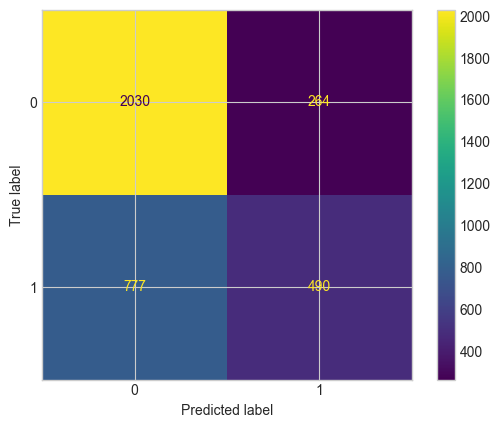

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, model_pred)
plt.show()

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model_pred))
print(classification_report(y_test, model_pred, target_names=['NOBurgStatus', 'BurgStatus'], digits=4))

              precision    recall  f1-score   support

           0       0.72      0.88      0.80      2294
           1       0.65      0.39      0.48      1267

    accuracy                           0.71      3561
   macro avg       0.69      0.64      0.64      3561
weighted avg       0.70      0.71      0.69      3561

              precision    recall  f1-score   support

NOBurgStatus     0.7232    0.8849    0.7959      2294
  BurgStatus     0.6499    0.3867    0.4849      1267

    accuracy                         0.7077      3561
   macro avg     0.6865    0.6358    0.6404      3561
weighted avg     0.6971    0.7077    0.6853      3561



In [46]:
from sklearn.metrics import precision_score, recall_score
recall=recall_score(y_test, model_pred)
recall_format='Recall Score: {0:4f}'.format(recall)
print(recall_format)
print('')
precision=precision_score(y_test, model_pred)
precision_format='Precison Score: {0:4f}'.format(precision)
print(precision_format)

Recall Score: 0.386740

Precison Score: 0.649867


AUC: 0.7183765479969365


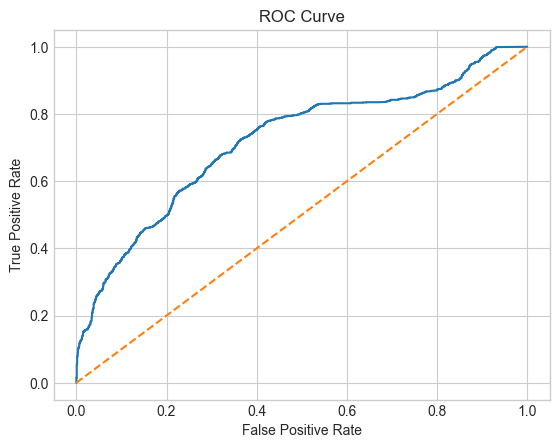

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**6.2 Using Logistic Regression create a model using scaled data**

In [48]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

scales = [
    (X_train,    X_test,    "Raw"),
    (X_train_sc, X_test_sc, "StdScale"),
    (X_train_mm, X_test_mm, "MinMax"),
    (X_train_rb, X_test_rb, "Robust"),
    (X_train_nm, X_test_nm, "Normal"),
]

model = LogisticRegression(random_state=21)



df_results_scaled = pd.DataFrame(y_test).reset_index()

for vartrain, vartest, name in scales:
    print("\n" + "="*60)
    print(f"Scaling Method: {name}")
    print("="*60)

    # Train
    model.fit(vartrain, y_train)
    score = model.score(vartest,y_test)

    model_pred = model.predict(vartest)
    df_model_pred = pd.DataFrame(model_pred, columns=[name])

    df_results_scaled = pd.concat([df_results_scaled, df_model_pred], axis=1)

    print('---------------------')

    print('Results:',  name)
    display(round(score,6))
    print(confusion_matrix(y_test, model_pred))
df_results_scaled.sample(10, random_state=102)


Scaling Method: Raw
---------------------
Results: Raw


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.707666

[[2030  264]
 [ 777  490]]

Scaling Method: StdScale
---------------------
Results: StdScale


0.805673

[[2083  211]
 [ 481  786]]

Scaling Method: MinMax
---------------------
Results: MinMax


0.804549

[[2104  190]
 [ 506  761]]

Scaling Method: Robust
---------------------
Results: Robust


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.808481

[[2088  206]
 [ 476  791]]

Scaling Method: Normal
---------------------
Results: Normal


0.644201

[[2294    0]
 [1267    0]]


,index,BurgStatus,Raw,StdScale,MinMax,Robust,Normal
323,2183,1,0,0,0,0,0
2375,11570,1,1,0,0,0,0
1420,10644,0,0,0,0,0,0
2016,2168,0,0,0,0,0,0
2860,5496,0,0,0,0,0,0
225,3546,0,0,0,0,0,0
3084,10374,0,1,0,0,0,0
1534,8742,1,1,0,0,0,0
2103,4271,0,0,0,0,0,0
1155,3941,1,0,0,0,0,0


## 6.3 Fine-tune the model to find the OPTIMAL model

Among the scaling methods evaluated, Robust Scaling produced the strongest performance, achieving the highest AUC (0.878) and the best recall (0.623) for burglary detection. This suggests that the presence of outliers and skewed demographic features benefits from median-based scaling rather than standard normalization. Raw (unscaled) features resulted in poor convergence and substantially lower predictive performance.

In [49]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

C_penalty = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

vartrain = X_train_rb
vartest  = X_test_rb

best_acc = -1
best_C = None
scores = []

for c in C_penalty:
    model = LogisticRegression(C=c, random_state=21, max_iter=5000)
    model.fit(vartrain, y_train)

    acc = model.score(vartest, y_test)
    scores.append({"C": c, "Accuracy": acc})

    print("C:", c, "Accuracy:", round(acc, 6))

    if acc > best_acc:
        best_acc = acc
        best_C = c

df_C_scores = pd.DataFrame(scores).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\nBest C:", best_C)
print("Best Accuracy:", round(best_acc, 6))

df_C_scores

C: 0.001 Accuracy: 0.795563
C: 0.01 Accuracy: 0.803426
C: 0.1 Accuracy: 0.807077
C: 1 Accuracy: 0.806234
C: 10 Accuracy: 0.806515
C: 100 Accuracy: 0.805392
C: 1000 Accuracy: 0.805392

Best C: 0.1
Best Accuracy: 0.807077


,C,Accuracy
0,0.100,0.807077
1,10.000,0.806515
2,1.000,0.806234
3,100.000,0.805392
4,1000.000,0.805392
5,0.010,0.803426
6,0.001,0.795563


In [50]:
# Fit best model
best_model = LogisticRegression(C=best_C, random_state=21)
best_model.fit(vartrain, y_train)

# Predictions + Probabilities
model_pred = best_model.predict(vartest)
model_prob = best_model.predict_proba(vartest)

# Create formatted tables like you wanted
model_pred_df = pd.DataFrame(model_pred, columns=["Predict_OPT_log"])

model_prob_df = pd.DataFrame(
    model_prob,
    columns=["Prob_OPT_NoBurglary", "Prob_OPT_Burglary"]
)

# Combine with actual y_test
df_model_results_OPT = pd.DataFrame({"BurgStatus": y_test.reset_index(drop=True)})
df_model_results_OPT = pd.concat([df_model_results, model_pred_df, model_prob_df], axis=1)

# Optional: add correctness column
df_model_results_OPT["Correct"] = (df_model_results["BurgStatus"] == df_model_results["Predict_log"])

df_model_results_OPT=df_model_results_OPT.drop(['index', 'All_comp', 'Arrest_comp', 'Correct'], axis=1)
df_model_results_OPT = df_model_results_OPT.loc[:, ~df_model_results_OPT.columns.duplicated()]
df_model_results_OPT=df_model_results_OPT.drop(['prob_OPT_Burglary'],axis=1)

df_model_results_OPT.sample(10, random_state=244)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,BurgStatus,Predict_log,Prob_OPT_NoBurglary,Predict_OPT_log,Prob_OPT_Burglary
2621,0,0,0.737782,0,0.086512
975,1,0,0.774263,0,0.138538
368,0,0,0.744687,0,0.209409
1488,0,0,0.835722,0,0.220494
1712,0,0,0.732147,0,0.156556
229,0,0,0.744671,1,0.938641
951,1,0,0.540967,0,0.471293
1755,1,1,0.371719,1,0.793086
2846,1,0,0.540682,0,0.428703
485,0,0,0.744630,0,0.437853


## 6.4 Fine-tune the model to find the DECISION model

*changing class weight*

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

cw = [None, 'balanced', {0:1, 1:1.5}, {0:1, 1:2}, {0:1, 1:3}, {0:1, 1:4}]

vartrain = X_train_rb
vartest  = X_test_rb

best_f1 = 0
best_cw = None

for w in cw:
    model = LogisticRegression(class_weight=w, C=10, random_state=21, max_iter=5000)
    model.fit(vartrain, y_train)

    pred = model.predict(vartest)

    precision = precision_score(y_test, pred, pos_label=1, zero_division=0)
    recall    = recall_score(y_test, pred, pos_label=1, zero_division=0)
    f1        = f1_score(y_test, pred, pos_label=1, zero_division=0)

    print("Class Weight:", w)
    print("Precision:", round(precision,4),
          "Recall:", round(recall,4),
          "F1:", round(f1,4))
    print("------------------------------------------------")

    if f1 > best_f1:
        best_f1 = f1
        best_cw = w

print("\nBest Class Weight (by F1):", best_cw)
print("Best F1:", round(best_f1,4))


Class Weight: None
Precision: 0.7884 Recall: 0.6235 F1: 0.6963
------------------------------------------------
Class Weight: balanced
Precision: 0.7178 Recall: 0.753 F1: 0.735
------------------------------------------------
Class Weight: {0: 1, 1: 1.5}
Precision: 0.7419 Recall: 0.7214 F1: 0.7315
------------------------------------------------
Class Weight: {0: 1, 1: 2}
Precision: 0.6999 Recall: 0.7806 F1: 0.7381
------------------------------------------------
Class Weight: {0: 1, 1: 3}
Precision: 0.6476 Recall: 0.8587 F1: 0.7384
------------------------------------------------
Class Weight: {0: 1, 1: 4}
Precision: 0.6028 Recall: 0.8958 F1: 0.7206
------------------------------------------------

Best Class Weight (by F1): {0: 1, 1: 3}
Best F1: 0.7384


In [52]:
model = LogisticRegression(
    class_weight=best_cw,
    C=10,
    random_state=21,
)

model.fit(vartrain, y_train)

model_pred = model.predict(vartest)
model_prob = model.predict_proba(vartest)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
model_pred_df = pd.DataFrame(model_pred, columns=['Predict_DEC_log'])

In [54]:
model_prob_df = pd.DataFrame(
    model_prob,
    columns=['Prob_DEC_NoBurglary', 'Prob_DEC_Burglary']
)

In [55]:
df_model_results_DEC = pd.DataFrame(y_test).reset_index(drop=True)

df_model_results_DEC = pd.concat(
    [df_model_results, model_pred_df, model_prob_df],
    axis=1
)
df_model_results_DEC=df_model_results_DEC.drop(['index','Predict_log', 'All_comp', 'Arrest_comp'], axis=1)
df_model_results_DEC = df_model_results_DEC.loc[:, ~df_model_results_DEC.columns.duplicated()]
df_model_results_DEC=df_model_results_DEC.drop(['Prob_OPT_NoBurglary', 'prob_OPT_Burglary'], axis=1)


df_model_results_DEC.sample(10, random_state=244)

,BurgStatus,Predict_DEC_log,Prob_DEC_NoBurglary,Prob_DEC_Burglary
2621,0,0,0.812881,0.187119
975,1,0,0.718769,0.281231
368,0,0,0.583255,0.416745
1488,0,0,0.548747,0.451253
1712,0,0,0.679858,0.320142
229,0,1,0.010981,0.989019
951,1,1,0.267940,0.732060
1755,1,1,0.080971,0.919029
2846,1,1,0.313277,0.686723
485,0,1,0.254140,0.745860


## 6.5 Comments throughout Section 6 – and Summary Table

In [56]:
df_model_results = pd.concat(
    [df_model_results_OPT, df_model_results_DEC.drop(columns=["BurgStatus"])],
    axis=1
)

In [57]:
df_model_results.sample(10, random_state=244)

,BurgStatus,Predict_log,Prob_OPT_NoBurglary,Predict_OPT_log,Prob_OPT_Burglary,Predict_DEC_log,Prob_DEC_NoBurglary,Prob_DEC_Burglary
2621,0,0,0.737782,0,0.086512,0,0.812881,0.187119
975,1,0,0.774263,0,0.138538,0,0.718769,0.281231
368,0,0,0.744687,0,0.209409,0,0.583255,0.416745
1488,0,0,0.835722,0,0.220494,0,0.548747,0.451253
1712,0,0,0.732147,0,0.156556,0,0.679858,0.320142
229,0,0,0.744671,1,0.938641,1,0.010981,0.989019
951,1,0,0.540967,0,0.471293,1,0.267940,0.732060
1755,1,1,0.371719,1,0.793086,1,0.080971,0.919029
2846,1,0,0.540682,0,0.428703,1,0.313277,0.686723
485,0,0,0.744630,0,0.437853,1,0.254140,0.745860


* Logistic regression model with raw data: The logistic regression model trained on raw data achieves an overall accuracy of approximately 71%, indicating moderate predictive performance. The model performs reasonably well for the majority class (No Burglary), achieving a precision of 0.72 and a recall of 0.88, meaning it correctly identifies most non-burglary weeks. However, performance drops substantially for the burglary class. While the precision for burglary is 0.65—meaning that when the model predicts a burglary, it is correct about 65% of the time—the recall is only 0.39. This indicates that the model detects less than 40% of actual burglary cases, missing more than half of them. The F1-score for burglary is 0.48, reflecting this imbalance between precision and recall. Overall, the model is biased toward predicting the majority class and struggles to effectively capture burglary events, suggesting that further tuning or alternative modeling approaches may be necessary if burglary detection is the primary objective.
* The logistic regression results show a clear improvement in performance when feature scaling is applied. Using raw data, the model achieves an accuracy of approximately 0.708, with a relatively high number of false negatives (777), indicating poor burglary detection. The convergence warning also suggests that the optimization struggled without scaling. After applying scaling methods such as StandardScaler, MinMaxScaler, and RobustScaler, performance improves substantially. Standard scaling yields an accuracy of 0.806, MinMax scaling achieves 0.805, and Robust scaling performs slightly best at 0.808. In particular, Robust scaling reduces false negatives to 476 and increases true positives to 791, demonstrating improved burglary detection compared to the raw model. These results indicate that logistic regression benefits significantly from properly scaled features, leading to better convergence and stronger predictive performance.

## 7. Classification using Decision Tree Modeling

## 7.1 Using Decision Tree Modeling create a model using the raw data

In [58]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# Create model
model = DecisionTreeClassifier(random_state=21)

# Fit
model.fit(X_train, y_train)

# Predictions
model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)

print(model_pred)
model_prob

# Convert predictions to dataframe
model_pred = pd.DataFrame(model_pred)
model_pred = model_pred.rename(columns={0: 'Predict_DEC'})

model_prob = pd.DataFrame(model_prob)
model_prob = model_prob.rename(
    columns={
        0: 'Prob_DEC_NoBurglary',
        1: 'Prob_DEC_Burglary'
    }
)

display(model_pred.sample(5, random_state=244))
model_prob.sample(5, random_state=244)

df_model_results_DEC = pd.DataFrame({"BurgStatus": y_test.reset_index(drop=True)})

df_model_results_DEC = pd.concat(
    [df_model_results_DEC, model_pred, model_prob],
    axis=1
)

df_model_results_DEC.head()


[0 1 0 ... 0 0 1]


,Predict_DEC
2621,0
975,0
368,0
1488,0
1712,1


,BurgStatus,Predict_DEC,Prob_DEC_NoBurglary,Prob_DEC_Burglary
0,0,0,1.000000,0.000000
1,1,1,0.000000,1.000000
2,0,0,0.986301,0.013699
3,1,1,0.000000,1.000000
4,0,0,1.000000,0.000000


CV Accuracy scores: [0.756919 0.740072 0.737665 0.76775  0.722022 0.754513 0.756919 0.757831
 0.728916 0.73494 ]
Mean CV Accuracy: 0.745755
Std CV Accuracy: 0.014203

Confusion Matrix:
[[1874  420]
 [ 460  807]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2294
           1       0.66      0.64      0.65      1267

    accuracy                           0.75      3561
   macro avg       0.73      0.73      0.73      3561
weighted avg       0.75      0.75      0.75      3561



<Figure size 640x480 with 0 Axes>

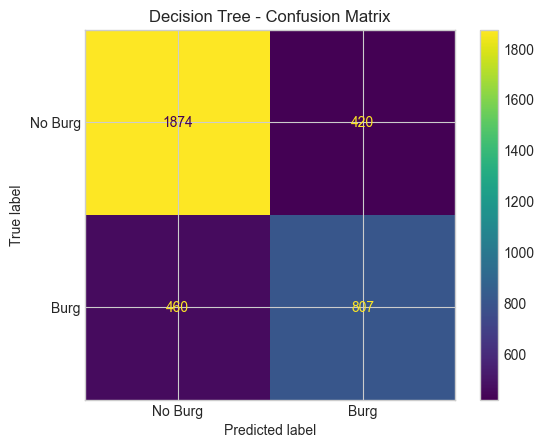

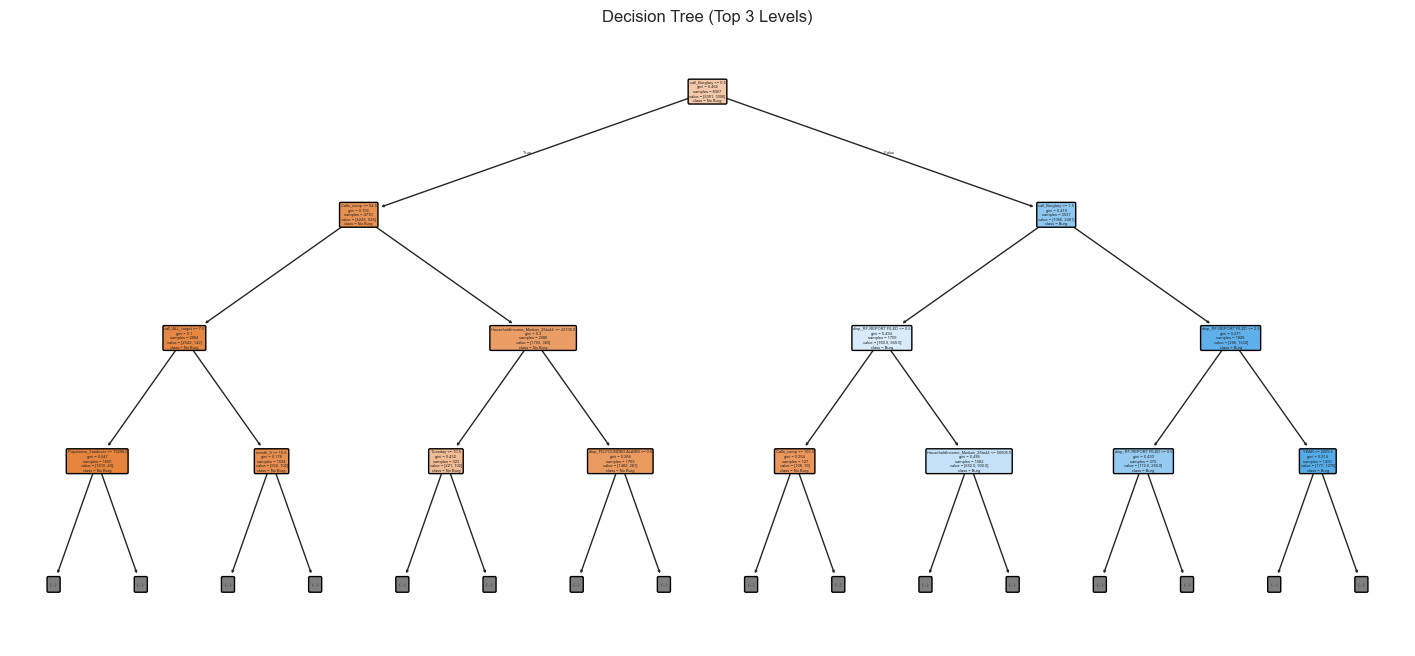

In [59]:
# Decision Tree: cross-val score, confusion matrix, classification report,
# plot decision tree, plot confusion matrix

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ----------------------------
# 1) Define model
# ----------------------------
dt_model = DecisionTreeClassifier(random_state=21)

# ----------------------------
# 2) Cross-validation score (Accuracy)
# ----------------------------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring="accuracy")

print("CV Accuracy scores:", np.round(cv_scores, 6))
print("Mean CV Accuracy:", round(cv_scores.mean(), 6))
print("Std CV Accuracy:", round(cv_scores.std(), 6))

# ----------------------------
# 3) Fit on train, predict on test
# ----------------------------
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

# ----------------------------
# 4) Confusion matrix + classification report
# ----------------------------
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# ----------------------------
# 5) Plot confusion matrix
# ----------------------------
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Burg", "Burg"]
)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# ----------------------------
# 6) Plot decision tree
#    (If you have many features, this plot will be huge.
#     In that case set max_depth=3 or 4 just for visualization.)
# ----------------------------
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    filled=True,
    rounded=True,
    max_depth=3,                  # show top levels only (change if you want)
    feature_names=getattr(X_train, "columns", None),
    class_names=["No Burg", "Burg"]
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()


## 7.2 Using Decision Tree Modeling create a model using scaled data

In [60]:
# Create model
model = DecisionTreeClassifier(random_state=21)

# Fit
model.fit(X_train_sc, y_train)

# Predictions
model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)

print(model_pred)
model_prob

# Convert predictions to dataframe
model_pred = pd.DataFrame(model_pred)
model_pred = model_pred.rename(columns={0: 'Predict_DEC'})

model_prob = pd.DataFrame(model_prob)
model_prob = model_prob.rename(
    columns={
        0: 'Prob_DEC_NoBurglary',
        1: 'Prob_DEC_Burglary'
    }
)

display(model_pred.sample(5, random_state=244))
model_prob.sample(5, random_state=244)

df_model_results_DEC = pd.DataFrame({"BurgStatus": y_test.reset_index(drop=True)})

df_model_results_DEC = pd.concat(
    [df_model_results_DEC, model_pred, model_prob],
    axis=1
)

df_model_results_DEC.head()


[1 1 0 ... 0 0 1]


,Predict_DEC
2621,0
975,1
368,1
1488,1
1712,1


,BurgStatus,Predict_DEC,Prob_DEC_NoBurglary,Prob_DEC_Burglary
0,0,1,0.0,1.0
1,1,1,0.0,1.0
2,0,0,1.0,0.0
3,1,1,0.0,1.0
4,0,0,1.0,0.0


CV Accuracy scores: [0.756919 0.740072 0.737665 0.76775  0.722022 0.754513 0.756919 0.757831
 0.728916 0.73494 ]
Mean CV Accuracy: 0.745755
Std CV Accuracy: 0.014203

Confusion Matrix:
[[1874  420]
 [ 460  807]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2294
           1       0.66      0.64      0.65      1267

    accuracy                           0.75      3561
   macro avg       0.73      0.73      0.73      3561
weighted avg       0.75      0.75      0.75      3561



<Figure size 640x480 with 0 Axes>

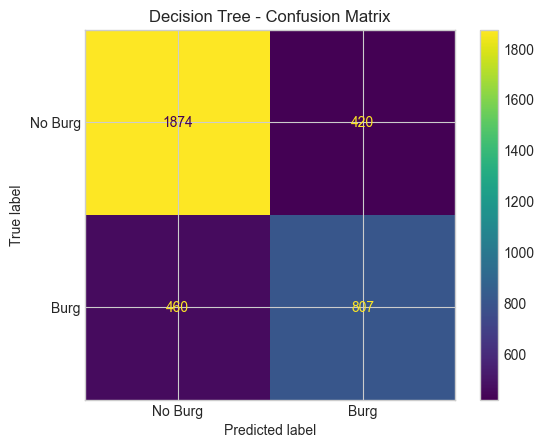

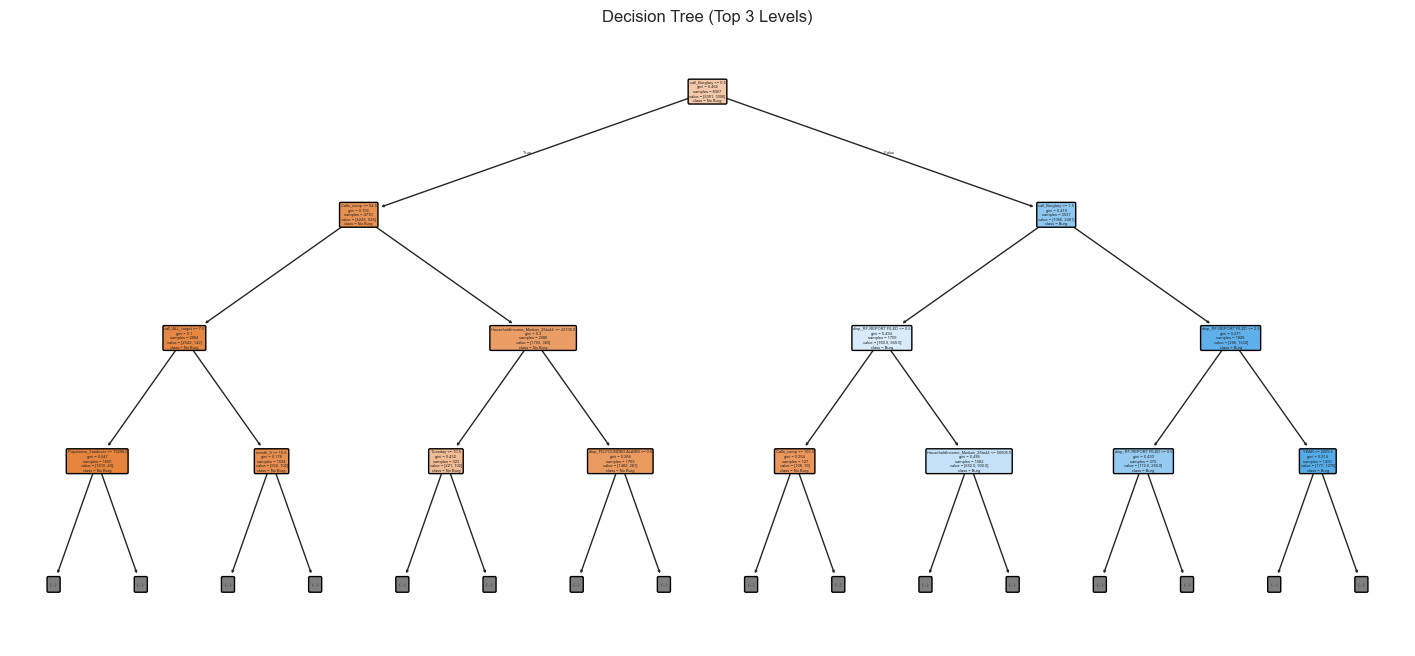

In [61]:
# Decision Tree: cross-val score, confusion matrix, classification report,
# plot decision tree, plot confusion matrix

import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ----------------------------
# 1) Define model
# ----------------------------
dt_model = DecisionTreeClassifier(random_state=21)

# ----------------------------
# 2) Cross-validation score (Accuracy)
# ----------------------------
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=21)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring="accuracy")

print("CV Accuracy scores:", np.round(cv_scores, 6))
print("Mean CV Accuracy:", round(cv_scores.mean(), 6))
print("Std CV Accuracy:", round(cv_scores.std(), 6))

# ----------------------------
# 3) Fit on train, predict on test
# ----------------------------
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

# ----------------------------
# 4) Confusion matrix + classification report
# ----------------------------
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# ----------------------------
# 5) Plot confusion matrix
# ----------------------------
plt.figure()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Burg", "Burg"]
)
plt.title("Decision Tree - Confusion Matrix")
plt.show()


# ----------------------------
# 6) Plot decision tree
#    (If you have many features, this plot will be huge.
#     In that case set max_depth=3 or 4 just for visualization.)
# ----------------------------
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    filled=True,
    rounded=True,
    max_depth=3,                  # show top levels only (change if you want)
    feature_names=getattr(X_train, "columns", None),
    class_names=["No Burg", "Burg"]
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()


In [62]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

scales = [
    (X_train,    X_test,    "Raw"),
    (X_train_sc, X_test_sc, "StdScale"),
    (X_train_mm, X_test_mm, "MinMax"),
    (X_train_rb, X_test_rb, "Robust"),
    (X_train_nm, X_test_nm, "Normal"),
]

model = DecisionTreeClassifier(random_state=21)

df_results_scaled = pd.DataFrame(y_test).reset_index()

for vartrain, vartest, name in scales:
    print("\n" + "="*60)
    print(f"Scaling Method: {name}")
    print("="*60)

    # Train
    model.fit(vartrain, y_train)
    score = model.score(vartest,y_test)

    model_pred = model.predict(vartest)
    df_model_pred = pd.DataFrame(model_pred, columns=[name])

    df_results_scaled = pd.concat([df_results_scaled, df_model_pred], axis=1)

    print('---------------------')

    print('Results:',  name)
    display(round(score,6))
    print(confusion_matrix(y_test, model_pred))
df_results_scaled.sample(10, random_state=102)


Scaling Method: Raw
---------------------
Results: Raw


0.752878

[[1874  420]
 [ 460  807]]

Scaling Method: StdScale
---------------------
Results: StdScale


0.751193

[[1874  420]
 [ 466  801]]

Scaling Method: MinMax
---------------------
Results: MinMax


0.750913

[[1871  423]
 [ 464  803]]

Scaling Method: Robust
---------------------
Results: Robust


0.751755

[[1869  425]
 [ 459  808]]

Scaling Method: Normal
---------------------
Results: Normal


0.745858

[[1866  428]
 [ 477  790]]


,index,BurgStatus,Raw,StdScale,MinMax,Robust,Normal
323,2183,1,0,0,0,0,0
2375,11570,1,1,1,1,1,1
1420,10644,0,1,1,1,1,1
2016,2168,0,0,0,0,0,0
2860,5496,0,0,0,0,0,0
225,3546,0,0,0,0,0,0
3084,10374,0,0,0,0,0,0
1534,8742,1,0,0,0,0,1
2103,4271,0,0,0,0,0,0
1155,3941,1,1,1,1,1,1


## 7.3 Fine-tune the model to find the OPTIMAL model

In [63]:
depth_list = [1, 2, 3, 4, 5, 8, 10, 15, None]

best_acc = -1
best_depth = None
scores = []

for d in depth_list:
    model = DecisionTreeClassifier(random_state=21, max_depth=d)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    scores.append({"max_depth": d, "Accuracy": acc})

    print("max_depth:", d, "Accuracy:", round(acc, 6))

    if acc > best_acc:
        best_acc = acc
        best_depth = d

df_depth_scores = pd.DataFrame(scores).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\nBest max_depth:", best_depth)
print("Best Accuracy:", round(best_acc, 6))

df_depth_scores

max_depth: 1 Accuracy: 0.823645
max_depth: 2 Accuracy: 0.823645
max_depth: 3 Accuracy: 0.832912
max_depth: 4 Accuracy: 0.834035
max_depth: 5 Accuracy: 0.831508
max_depth: 8 Accuracy: 0.82196
max_depth: 10 Accuracy: 0.806515
max_depth: 15 Accuracy: 0.779837
max_depth: None Accuracy: 0.752878

Best max_depth: 4
Best Accuracy: 0.834035


,max_depth,Accuracy
0,4.0,0.834035
1,3.0,0.832912
2,5.0,0.831508
3,1.0,0.823645
4,2.0,0.823645
5,8.0,0.821960
6,10.0,0.806515
7,15.0,0.779837
8,NaN,0.752878


**Extract Best Depth**

In [64]:
best_depth = df_depth_scores.loc[0, "max_depth"]

print("Best max_depth:", best_depth)

Best max_depth: 4.0


**Re-train Decision Tree Using Best Depth**

In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report

best_depth = int(df_depth_scores.loc[0, "max_depth"])

best_model = DecisionTreeClassifier(
    random_state=21,
    max_depth=best_depth
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)

print("Accuracy:", round(best_model.score(X_test, y_test), 6))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.834035

Confusion Matrix:
[[1922  372]
 [ 219 1048]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87      2294
           1       0.74      0.83      0.78      1267

    accuracy                           0.83      3561
   macro avg       0.82      0.83      0.82      3561
weighted avg       0.84      0.83      0.84      3561



In [66]:
import pandas as pd

model_pred_df = pd.DataFrame(y_pred, columns=["Predict_OPT"])

model_prob_df = pd.DataFrame(
    y_prob,
    columns=["Prob_OPT_NoBurglary", "Prob_OPT_Burglary"]
)

df_model_results_OPT = pd.DataFrame({
    "BurgStatus": y_test.reset_index(drop=True)
})

df_model_results_OPT = pd.concat(
    [df_model_results_OPT, model_pred_df, model_prob_df],
    axis=1
)


df_model_results_OPT.sample(10, random_state=244)

,BurgStatus,Predict_OPT,Prob_OPT_NoBurglary,Prob_OPT_Burglary
2621,0,0,0.978580,0.021420
975,1,1,0.464365,0.535635
368,0,0,0.849220,0.150780
1488,0,0,0.908012,0.091988
1712,0,0,0.908012,0.091988
229,0,1,0.233677,0.766323
951,1,1,0.343567,0.656433
1755,1,1,0.286932,0.713068
2846,1,1,0.343567,0.656433
485,0,1,0.464365,0.535635


In [67]:


importances = best_model.feature_importances_
feature_names = X_train.columns

df_importance_OPT = pd.DataFrame({
    "Feature": feature_names,
    "dt_importance": importances
}).sort_values("dt_importance", ascending=False)

df_importance_OPT.head(20)   # top 20


,Feature,dt_importance
48,call_Burglary,0.889352
93,disp_RF-REPORT FILED,0.044732
8,Calls_comp,0.027116
126,HouseholdIncome_Median_25to44,0.014057
80,disp_FD-FOUNDED ALARM,0.008047
24,YEAR,0.005185
20,call_ALL_target,0.004007
31,Tuesday,0.003680
41,month_9,0.002294
109,Population_3andover,0.001529


**7.4 Fine-tune the model to find the DECISION model**

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

depth_list = [1, 2, 3, 4, 5, 8, 10, 15, None]

best_f1 = -1
best_depth = None
scores = []

for d in depth_list:
    model = DecisionTreeClassifier(random_state=21, max_depth=d, class_weight='balanced')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    scores.append({
        "max_depth": d,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print("max_depth:", d,
          "Precision:", round(precision,4),
          "Recall:", round(recall,4),
          "F1:", round(f1,4))

    if f1 > best_f1:
        best_f1 = f1
        best_depth = d

df_depth_scores = (
    pd.DataFrame(scores)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

print("\nBest max_depth (by F1):", best_depth)
print("Best F1:", round(best_f1,4))

df_depth_scores


max_depth: 1 Precision: 0.705 Recall: 0.8374 F1: 0.7655
max_depth: 2 Precision: 0.705 Recall: 0.8374 F1: 0.7655
max_depth: 3 Precision: 0.7365 Recall: 0.8208 F1: 0.7764
max_depth: 4 Precision: 0.7207 Recall: 0.839 F1: 0.7753
max_depth: 5 Precision: 0.7203 Recall: 0.8232 F1: 0.7683
max_depth: 8 Precision: 0.714 Recall: 0.8098 F1: 0.7589
max_depth: 10 Precision: 0.6976 Recall: 0.7901 F1: 0.7409
max_depth: 15 Precision: 0.6794 Recall: 0.7427 F1: 0.7097
max_depth: None Precision: 0.664 Recall: 0.6456 F1: 0.6547

Best max_depth (by F1): 3
Best F1: 0.7764


,max_depth,Precision,Recall,F1
0,3.0,0.736544,0.820837,0.776409
1,4.0,0.720678,0.838990,0.775346
2,5.0,0.720304,0.823204,0.768324
3,1.0,0.704983,0.837411,0.765512
4,2.0,0.704983,0.837411,0.765512
5,8.0,0.713987,0.809787,0.758876
6,10.0,0.697561,0.790055,0.740933
7,15.0,0.679422,0.742699,0.709653
8,NaN,0.663961,0.645620,0.654662


In [69]:
if best_depth is not None:
    best_depth = int(best_depth)

final_model = DecisionTreeClassifier(
    random_state=21,
    max_depth=best_depth
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("\nFinal Model Accuracy:", round(final_model.score(X_test, y_test),6))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



Final Model Accuracy: 0.832912

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87      2294
           1       0.74      0.82      0.78      1267

    accuracy                           0.83      3561
   macro avg       0.82      0.83      0.82      3561
weighted avg       0.84      0.83      0.83      3561



**Create Results Table**

In [70]:
model_pred_df = pd.DataFrame(y_pred, columns=["Predict_DEC"])

model_prob_df = pd.DataFrame(
    y_prob,
    columns=["Prob_DEC_NoBurglary", "Prob_DEC_Burglary"]
)

df_model_results_DEC = pd.DataFrame({
    "BurgStatus": y_test.reset_index(drop=True)
})

df_model_results_DEC = pd.concat(
    [df_model_results_OPT, model_pred_df, model_prob_df],
    axis=1
)


df_model_results_DEC.sample(10, random_state=244)

,BurgStatus,Predict_OPT,Prob_OPT_NoBurglary,Prob_OPT_Burglary,Predict_DEC,Prob_DEC_NoBurglary,Prob_DEC_Burglary
2621,0,0,0.978580,0.021420,0,0.978580,0.021420
975,1,1,0.464365,0.535635,1,0.464365,0.535635
368,0,0,0.849220,0.150780,0,0.849220,0.150780
1488,0,0,0.908012,0.091988,0,0.908012,0.091988
1712,0,0,0.908012,0.091988,0,0.908012,0.091988
229,0,1,0.233677,0.766323,1,0.233677,0.766323
951,1,1,0.343567,0.656433,1,0.343567,0.656433
1755,1,1,0.286932,0.713068,1,0.286932,0.713068
2846,1,1,0.343567,0.656433,1,0.343567,0.656433
485,0,1,0.464365,0.535635,1,0.464365,0.535635


In [71]:
import pandas as pd

importances = final_model.feature_importances_
feature_names = X_train.columns

df_importance_DEC = pd.DataFrame({
    "Feature": feature_names,
    "dt_3_importance": importances
}).sort_values("dt_3_importance", ascending=False)

df_importance_DEC.head(20)   # top 20
#print(df_importance_DEC.to_string(index=False))
#df_importance_nonzero_2 = df_importance_DEC[df_importance["Importance"] > 0]
#df_importance_nonzero_2.head(30)

,Feature,dt_3_importance
48,call_Burglary,0.924012
93,disp_RF-REPORT FILED,0.040199
8,Calls_comp,0.023724
126,HouseholdIncome_Median_25to44,0.007901
20,call_ALL_target,0.004164
4,NoContact_comp,0.000000
0,All_comp,0.000000
1,FalseAlarm_comp,0.000000
7,Filed_comp,0.000000
6,Resolved_comp,0.000000


**Creating important feature table**

In [72]:
import pandas as pd

df_importance = pd.concat(
    [df_importance_OPT, df_importance_DEC],
    axis=1
)
df_importance = df_importance.loc[:, ~df_importance.columns.duplicated()]
df_importance

,Feature,dt_importance,dt_3_importance
48,call_Burglary,0.889352,0.924012
93,disp_RF-REPORT FILED,0.044732,0.040199
8,Calls_comp,0.027116,0.023724
126,HouseholdIncome_Median_25to44,0.014057,0.007901
80,disp_FD-FOUNDED ALARM,0.008047,0.000000
...,...,...,...
147,Subzone_ZONE6B,0.000000,0.000000
148,Subzone_ZONE6C,0.000000,0.000000
149,Subzone_ZONE7B,0.000000,0.000000
150,Subzone_ZONE7C,0.000000,0.000000


## Comments throughout Section 7 – and Summary Table

* With Raw data: The model trained on the raw data achieves an overall accuracy of 75%, indicating that it correctly classifies approximately three out of four cases. Performance is stronger for the majority class (no burglary), where the model achieves a precision of 0.80 and a recall of 0.82, meaning it reliably identifies non-burglary weeks. For the burglary class, the model attains a precision of 0.66 and a recall of 0.64, resulting in an F1-score of 0.65. This suggests moderate performance in detecting burglaries, but the model misses a notable portion of actual burglary cases, as reflected by 460 false negatives in the confusion matrix. Overall, while the model demonstrates balanced macro performance (macro F1 = 0.73), it performs better at identifying no-burglary instances than burglary cases, indicating room for improvement if burglary detection is the primary objective.

* with scaled data: With scaled data, the model achieves a mean cross-validation accuracy of approximately 0.746, with a low standard deviation of 0.014, indicating stable and consistent performance across folds. However, the test set results remain identical to those obtained with raw data, yielding an overall accuracy of 75%. The confusion matrix shows 1,874 true negatives and 807 true positives, alongside 420 false positives and 460 false negatives. For the no-burglary class (Class 0), the model maintains strong performance with a precision of 0.80 and recall of 0.82. For the burglary class (Class 1), precision is 0.66 and recall is 0.64, producing an F1-score of 0.65. This indicates moderate effectiveness in identifying burglary cases but still missing a substantial portion of them. Overall, while scaling improves numerical stability in cross-validation, it does not materially change the model’s predictive performance on the test data, and the model continues to perform better on the majority class than on burglary detection.

* Best accuracy with based depth model with raw data: Using the decision tree model tuned to the best depth for maximum accuracy, performance improves substantially, achieving an overall accuracy of 0.834 on the test set. The confusion matrix shows 1,922 true negatives and 1,048 true positives, with 372 false positives and only 219 false negatives. Compared with the earlier model, this reflects a meaningful reduction in missed burglary cases. For the no-burglary class (Class 0), the model attains a precision of 0.90 and recall of 0.84, indicating strong reliability when predicting non-burglary weeks. For the burglary class (Class 1), the model achieves a precision of 0.74 and a recall of 0.83, producing an F1-score of 0.78, which indicates much stronger burglary detection performance. Overall, the tuned decision tree provides a better balance between identifying burglaries and non-burglaries, with notably higher recall for burglaries while maintaining high overall accuracy.

* The feature importance results show that the model’s predictions are driven overwhelmingly by a small number of variables. The most dominant feature is call_Burglary, with an importance of 0.889 in the full decision tree and 0.924 in the depth-3 tree, indicating that this variable alone accounts for the vast majority of the model’s decision-making power. This suggests that prior burglary-related calls are the strongest predictor of burglary outcomes. The second most influential feature is disp_RF-REPORT FILED, contributing around 4–5% importance, followed by Calls_comp, which captures overall call volume and contributes roughly 2–3%. Socioeconomic information such as HouseholdIncome_Median_25to44 has a relatively small impact (around 1% or less), and disp_FD-FOUNDED ALARM contributes under 1%. Overall, the model relies heavily on prior burglary call activity, with other operational and demographic features playing comparatively minor roles.